# Euro500 Index Returns

Dieses Notebook enthält die Schritte 4–7 aus `Euro500_Portfolio` zur Berechnung des EURO500-Market-Returns und zum Vergleich mit STOXX-Benchmarks.


In [1]:
# --- Imports & configuration ---
from pathlib import Path
import pandas as pd
import numpy as np
import lseg.data as ld
import warnings
BASE_DIR = Path("/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data")
(DATA_DIR := BASE_DIR / "intermediate").mkdir(parents=True, exist_ok=True)
(CACHE_DATA_DIR := BASE_DIR / "cache").mkdir(parents=True, exist_ok=True)
warnings.filterwarnings(
    "ignore",
    message=r".*Downcasting behavior in `replace` is deprecated.*",
    category=FutureWarning,
    module=r"lseg\.data\._tools\._dataframe"
)


In [2]:
# --- Prerequisite data for Step 4 ---
EURO500_PATH = DATA_DIR / "euro500.parquet"
if not EURO500_PATH.exists():
    raise FileNotFoundError(f"Missing file: {EURO500_PATH}")
euro500 = pd.read_parquet(EURO500_PATH).copy()
print("Loaded:", EURO500_PATH)
print("Rows:", len(euro500))


Loaded: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/intermediate/euro500.parquet
Rows: 56500


## 3. Free-Float Market-Cap Weighted Index (Quarterly Rebalanced)

Portfolio construction:
- Compute constituent weights from free-float market cap at rebalance dates
- Hold weights within quarter
- Rebalance at the next quarter-end

Economic interpretation:
- A broad large-cap euro-area market proxy with time-varying composition.


In [3]:
def build_quarterly_ff_weights(euro500_df: pd.DataFrame) -> pd.DataFrame:
    required_base = ["quarter", "date", "effective_date", "mcap_eur", "FreeFloatPct"]
    missing_base = [c for c in required_base if c not in euro500_df.columns]
    if missing_base:
        raise ValueError(f"Missing required columns for weight build: {missing_base}")

    w = euro500_df.copy()

    # Backward compatibility: build firm_id if not yet present in loaded euro500.
    if "firm_id" not in w.columns:
        out = pd.Series(pd.NA, index=w.index, dtype="string")

        if "ISIN" in w.columns:
            v = w["ISIN"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("ISIN:" + v)

        if "RIC_current" in w.columns:
            v = w["RIC_current"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "RIC" in w.columns:
            v = w["RIC"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("RIC:" + v)

        if "SEDOL" in w.columns:
            v = w["SEDOL"].astype("string").str.strip()
            v = v.where(v.notna() & (v != ""), pd.NA)
            out = out.fillna("SEDOL:" + v)

        w["firm_id"] = out

    w["mcap_eur"] = pd.to_numeric(w["mcap_eur"], errors="coerce")
    w["FreeFloatPct"] = pd.to_numeric(w["FreeFloatPct"], errors="coerce")
    w["firm_id"] = w["firm_id"].astype("string").str.strip()
    w = w[w["firm_id"].notna() & (w["firm_id"] != "")].copy()

    # Supports both 0-100 and 0-1 free-float formats.
    ff_raw = pd.to_numeric(w["FreeFloatPct"], errors="coerce").to_numpy(dtype="float64", na_value=np.nan)
    ff_frac = np.where(ff_raw > 1.0, ff_raw / 100.0, ff_raw)
    w["ff_frac_used"] = pd.Series(ff_frac, index=w.index).clip(lower=0.0, upper=1.0)
    w["ff_frac_used"] = w["ff_frac_used"].fillna(1.0)

    w["ff_mcap_eur"] = w["mcap_eur"] * w["ff_frac_used"]
    w = w.dropna(subset=["ff_mcap_eur"]).copy()

    # Keep one line per quarter + firm_id (largest ff_mcap if duplicates exist).
    w = (
        w.sort_values(["quarter", "firm_id", "ff_mcap_eur"], ascending=[True, True, False])
        .drop_duplicates(subset=["quarter", "firm_id"], keep="first")
        .copy()
    )

    q_sum = w.groupby("quarter")["ff_mcap_eur"].transform("sum")
    w["weight_ff_mcap"] = np.where(q_sum > 0, w["ff_mcap_eur"] / q_sum, np.nan)

    out_cols = [
        "quarter",
        "date",
        "effective_date",
        "firm_id",
        "ISIN",
        "RIC",
        "name",
        "mcap_eur",
        "FreeFloatPct",
        "ff_frac_used",
        "ff_mcap_eur",
        "weight_ff_mcap",
        "rank_mcap",
    ]
    out_cols = [c for c in out_cols if c in w.columns]
    out = w[out_cols].sort_values(["quarter", "weight_ff_mcap"], ascending=[True, False]).reset_index(drop=True)
    return out


weights_ff = build_quarterly_ff_weights(euro500)

weights_qc = (
    weights_ff.groupby("quarter", as_index=False)
    .agg(
        n_constituents=("firm_id", "nunique"),
        weight_sum=("weight_ff_mcap", "sum"),
        ff_mcap_total=("ff_mcap_eur", "sum"),
    )
)
print("Quarterly weights quality check:")
display(weights_qc.head())
display(weights_qc.tail())



Quarterly weights quality check:


,quarter,n_constituents,weight_sum,ff_mcap_total
0,1998Q1,500,1.0,924974824254.137695
1,1998Q2,500,1.0,1368704672100.7146
2,1998Q3,500,1.0,1485947193115.250488
3,1998Q4,500,1.0,1152769034853.703857
4,1999Q1,500,1.0,1362409800770.108887


,quarter,n_constituents,weight_sum,ff_mcap_total
108,2025Q1,500,1.0,5681777172798.492188
109,2025Q2,500,1.0,6110905809377.236328
110,2025Q3,500,1.0,6318190626598.301758
111,2025Q4,500,1.0,6544643949657.299805
112,2026Q1,500,1.0,6843051270078.774414


## 4. Daily Market Return from In-Index Daily Company Returns

This step maps daily stock returns to index membership periods.

Method:
- Keep each firm's daily returns only while it is in the index
- Aggregate to a daily portfolio return using quarterly weights

Output:
- Clean daily return series for the EURO500 portfolio.


In [4]:
RETURNS_IN_INDEX_PATH = DATA_DIR / "euro500_daily_returns.parquet"
if not RETURNS_IN_INDEX_PATH.exists():
    raise FileNotFoundError(f"Missing file: {RETURNS_IN_INDEX_PATH}")

returns_in_index = pd.read_parquet(RETURNS_IN_INDEX_PATH)
returns_in_index["date"] = pd.to_datetime(returns_in_index["date"], errors="coerce")
returns_in_index["ret"] = pd.to_numeric(returns_in_index["ret"], errors="coerce")
returns_in_index["quarter"] = returns_in_index["quarter"].astype(str)


def _build_firm_id(df: pd.DataFrame) -> pd.Series:
    out = pd.Series(pd.NA, index=df.index, dtype="string")

    if "ISIN" in df.columns:
        v = df["ISIN"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("ISIN:" + v)

    if "RIC_current" in df.columns:
        v = df["RIC_current"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "RIC" in df.columns:
        v = df["RIC"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("RIC:" + v)

    if "SEDOL" in df.columns:
        v = df["SEDOL"].astype("string").str.strip()
        v = v.where(v.notna() & (v != ""), pd.NA)
        out = out.fillna("SEDOL:" + v)

    return out


if "firm_id" in returns_in_index.columns:
    returns_in_index["firm_id"] = returns_in_index["firm_id"].astype("string").str.strip()
    returns_in_index.loc[returns_in_index["firm_id"] == "", "firm_id"] = pd.NA
    # keep existing firm_id (expected: stable FIRMxxxx ids) and only fill true missing values
    returns_in_index["firm_id"] = returns_in_index["firm_id"].fillna(_build_firm_id(returns_in_index))
else:
    returns_in_index["firm_id"] = _build_firm_id(returns_in_index)

weights_join = weights_ff[["quarter", "firm_id", "weight_ff_mcap"]].copy()
weights_join["quarter"] = weights_join["quarter"].astype(str)
weights_join["firm_id"] = weights_join["firm_id"].astype(str).str.strip()

idx_daily = returns_in_index.merge(
    weights_join,
    on=["quarter", "firm_id"],
    how="inner",
)
idx_daily = idx_daily.dropna(subset=["date", "ret", "weight_ff_mcap"]).copy()
idx_daily["weighted_ret"] = idx_daily["ret"] * idx_daily["weight_ff_mcap"]

market_daily = (
    idx_daily
    .groupby(["date", "quarter"], as_index=False)
    .agg(
        market_return_num=("weighted_ret", "sum"),
        weight_available=("weight_ff_mcap", "sum"),
        n_constituents_with_return=("firm_id", "nunique"),
    )
)
market_daily["market_return_ffmcap"] = np.where(
    market_daily["weight_available"] > 0,
    market_daily["market_return_num"] / market_daily["weight_available"],
    np.nan,
)
MIN_WEIGHT_AVAILABLE = 0.80
market_daily["market_return_ffmcap_capped80"] = np.where(
    market_daily["weight_available"] >= MIN_WEIGHT_AVAILABLE,
    market_daily["market_return_ffmcap"],
    np.nan,
)

market_daily = market_daily.sort_values(["date", "quarter"]).reset_index(drop=True)
market_daily_out = market_daily[[
    "date",
    "quarter",
    "market_return_ffmcap",
    "market_return_ffmcap_capped80",
    "weight_available",
    "n_constituents_with_return",
]]

print("Saved daily market return series.")
print("Date range:", market_daily_out["date"].min(), "to", market_daily_out["date"].max())
print("Mean daily weight available:", round(float(market_daily_out["weight_available"].mean()), 4))
print(
    "Days dropped by 70% availability cap:",
    int(market_daily_out["market_return_ffmcap_capped80"].isna().sum()),
)
display(market_daily_out.head())
display(market_daily_out.tail())



Saved daily market return series.
Date range: 1998-01-02 00:00:00 to 2025-09-30 00:00:00
Mean daily weight available: 0.97
Days dropped by 70% availability cap: 98


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
0,1998-01-02,1998Q1,0.027136,0.027136,0.970649,407
1,1998-01-05,1998Q1,0.019075,0.019075,0.963910,420
2,1998-01-06,1998Q1,-0.005882,NaN,0.694494,286
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970215,422
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971234,424


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
7115,2025-09-24,2025Q3,-0.001161,-0.001161,0.98600,480
7116,2025-09-25,2025Q3,-0.004294,-0.004294,0.98565,480
7117,2025-09-26,2025Q3,0.008264,0.008264,0.98558,480
7118,2025-09-29,2025Q3,0.002185,0.002185,0.98601,481
7119,2025-09-30,2025Q3,0.004428,0.004428,0.98559,481


## 5. Market Index Diagnostics

Quality checks on the constructed return index, e.g.:
- Return distribution and outliers
- Coverage through time
- Missingness and continuity

Purpose:
- Confirm the index is empirically stable before benchmark comparison.


Market index diagnostics:
  obs_days: 7120
  start: 1998-01-02 00:00:00
  end: 2025-09-30 00:00:00
  mean_daily_return: 0.0004882934245929228
  vol_daily_return: 0.013888029370578503
  mean_daily_return_capped80: 0.00039701462468010366
  vol_daily_return_capped80: 0.013249382558286782
  mean_weight_available: 0.9700092029348067
  p5_weight_available: 0.88440135446903
  mean_constituents_with_return: 466.74143258426966


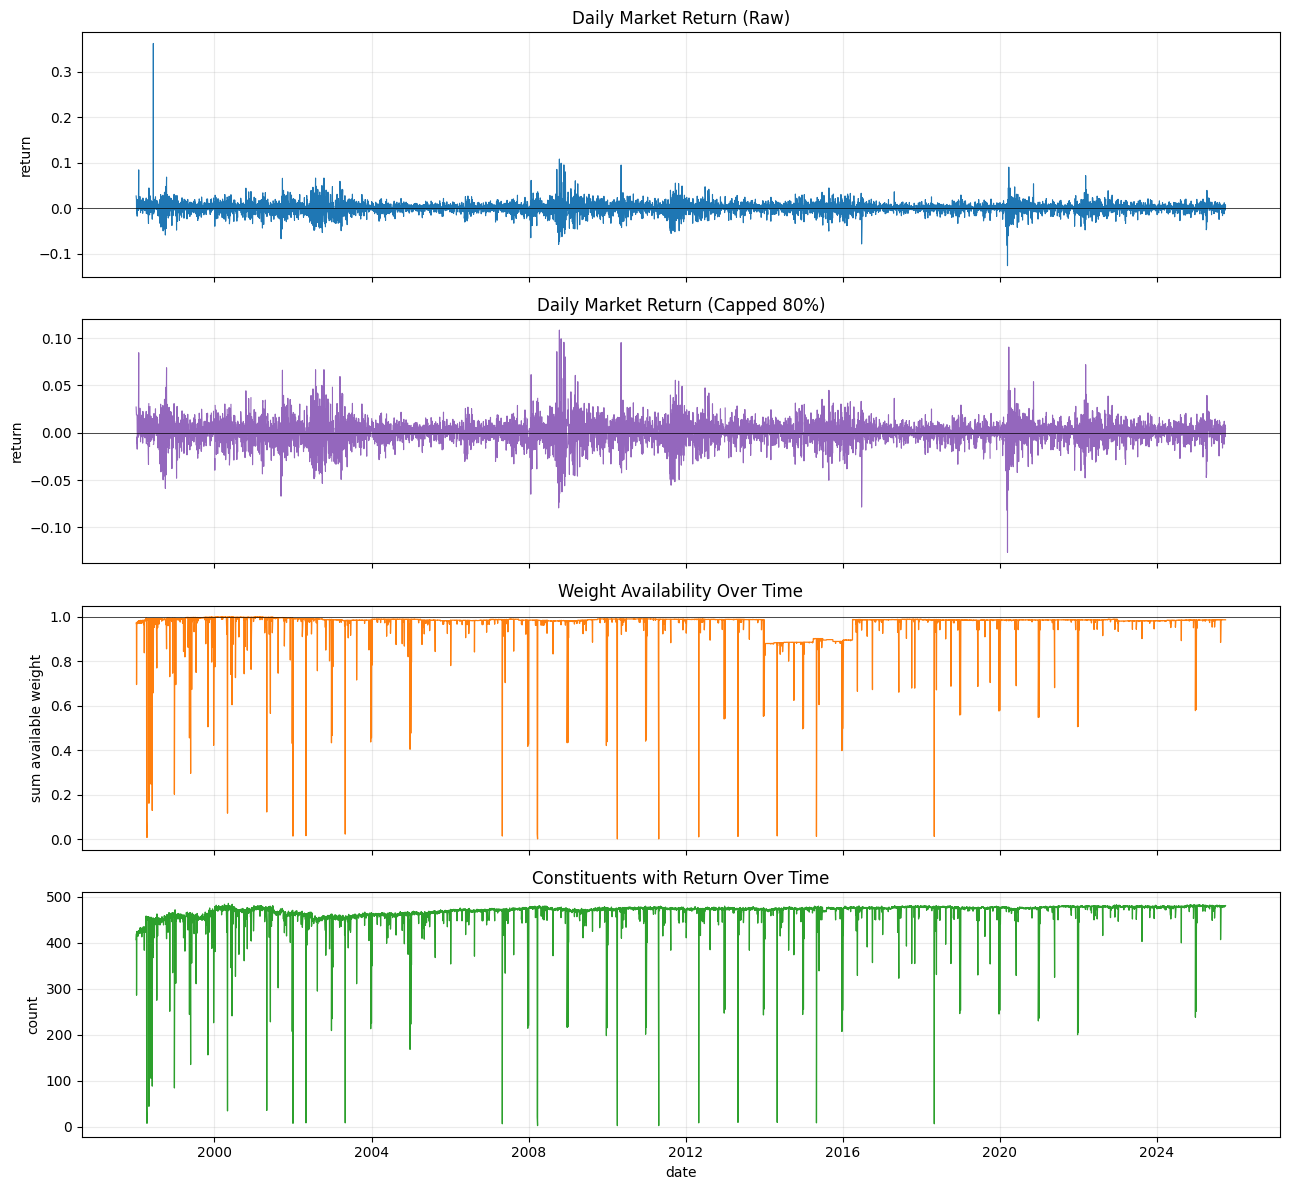

Worst 10 days by market return:


,date,quarter,market_return_ffmcap,weight_available,n_constituents_with_return
5696,2020-03-12,2020Q1,-0.126260,0.984196,476
5693,2020-03-09,2020Q1,-0.082038,0.984247,476
2763,2008-10-06,2008Q4,-0.079353,0.978657,473
4745,2016-06-24,2016Q2,-0.078469,0.939095,454
2767,2008-10-10,2008Q4,-0.073263,0.978020,473
949,2001-09-11,2001Q3,-0.066962,0.994984,468
2579,2008-01-21,2008Q1,-0.064852,0.984051,478
2770,2008-10-15,2008Q4,-0.064330,0.982689,475
2786,2008-11-06,2008Q4,-0.062415,0.981353,470
5698,2020-03-16,2020Q1,-0.060839,0.985118,477


Days with lowest weight availability:


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,n_constituents_with_return
3144,2010-04-05,2010Q2,0.023721,NaN,0.000448,2
3418,2011-04-25,2011Q2,0.004230,NaN,0.000613,2
2624,2008-03-24,2008Q1,-0.009919,NaN,0.000641,2
71,1998-04-13,1998Q2,0.000000,NaN,0.007076,7
3681,2012-05-01,2012Q2,0.010464,NaN,0.009725,8
3937,2013-05-01,2013Q2,0.008779,NaN,0.011695,9
5218,2018-05-01,2018Q2,0.004009,NaN,0.011815,6
4449,2015-05-01,2015Q2,0.011996,NaN,0.012009,8
1026,2001-12-31,2001Q4,0.000381,NaN,0.013370,7
2393,2007-05-01,2007Q2,0.003097,NaN,0.013629,6


In [5]:
import matplotlib.pyplot as plt

diag = market_daily_out.copy()
diag["date"] = pd.to_datetime(diag["date"], errors="coerce")
diag = diag.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

stats = {
    "obs_days": int(len(diag)),
    "start": diag["date"].min(),
    "end": diag["date"].max(),
    "mean_daily_return": float(diag["market_return_ffmcap"].mean()),
    "vol_daily_return": float(diag["market_return_ffmcap"].std()),
    "mean_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].mean()),
    "vol_daily_return_capped80": float(diag["market_return_ffmcap_capped80"].std()),
    "mean_weight_available": float(diag["weight_available"].mean()),
    "p5_weight_available": float(diag["weight_available"].quantile(0.05)),
    "mean_constituents_with_return": float(diag["n_constituents_with_return"].mean()),
}
print("Market index diagnostics:")
for k, v in stats.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

axes[0].plot(diag["date"], diag["market_return_ffmcap"], lw=0.8, color="tab:blue")
axes[0].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[0].set_title("Daily Market Return (Raw)")
axes[0].set_ylabel("return")
axes[0].grid(alpha=0.25)

axes[1].plot(diag["date"], diag["market_return_ffmcap_capped80"], lw=0.8, color="tab:purple")
axes[1].axhline(0.0, color="black", lw=0.7, alpha=0.7)
axes[1].set_title("Daily Market Return (Capped 80%)")
axes[1].set_ylabel("return")
axes[1].grid(alpha=0.25)

axes[2].plot(diag["date"], diag["weight_available"], color="tab:orange", lw=0.9)
axes[2].axhline(1.0, color="black", lw=0.7, alpha=0.7)
axes[2].set_title("Weight Availability Over Time")
axes[2].set_ylabel("sum available weight")
axes[2].grid(alpha=0.25)

axes[3].plot(diag["date"], diag["n_constituents_with_return"], color="tab:green", lw=0.9)
axes[3].set_title("Constituents with Return Over Time")
axes[3].set_ylabel("count")
axes[3].set_xlabel("date")
axes[3].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Worst 10 days by market return:")
display(
    diag.nsmallest(10, "market_return_ffmcap")[
        ["date", "quarter", "market_return_ffmcap", "weight_available", "n_constituents_with_return"]
    ]
)

print("Days with lowest weight availability:")
display(
    diag.nsmallest(10, "weight_available")[
        ["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available", "n_constituents_with_return"]
    ]
)


## 6. Benchmark Pull and Comparison (STOXX 600, STOXX EURO 50)

External benchmark data is pulled to evaluate tracking properties.

Comparison dimensions:
- Level and cumulative return paths
- Correlation and co-movement
- Relative performance across subperiods


In [6]:
def pull_index_daily_return(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    """
    Pull daily benchmark returns from LSEG using Total-Return-like fields only.
    """
    start = pd.to_datetime(start, errors="coerce")
    end = pd.to_datetime(end, errors="coerce")
    if pd.isna(start) or pd.isna(end):
        raise ValueError(f"Invalid benchmark date bounds for {ric}: start={start}, end={end}")

    start_str = start.strftime("%Y-%m-%d")
    end_str = end.strftime("%Y-%m-%d")

    tr_fields = [
        "TR.TotalReturn",
        "TR.IndexTotalReturn",
        "TR.IndexGrossReturn",
        "TR.IndexNetReturn",
    ]
    price_fields = [
        "TR.PriceClose",
        "CLOSE",
    ]

    last_err = None
    tried = []

    def _coerce_num(s: pd.Series) -> pd.Series:
        # Handles values like "0.45%", "1,234.5", etc.
        t = s.astype(str).str.replace("%", "", regex=False).str.replace(",", "", regex=False).str.strip()
        t = t.replace({"": np.nan, "None": np.nan, "nan": np.nan})
        return pd.to_numeric(t, errors="coerce")

    for field in tr_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            # Choose the column that yields the most numeric observations.
            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 0:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if out.empty:
                continue

            # TR-like series can come as percent points or decimals.
            max_abs = out["value"].abs().quantile(0.99)
            out["ret"] = out["value"] / 100.0 if max_abs > 1.5 else out["value"]
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = field
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    # Fallback for return-index RICs (e.g., .STOXXR/.STOXX50ER):
    # use index level (PriceClose/Close) and convert to daily returns.
    # This remains TR-consistent because the RIC itself is a return index.
    for field in price_fields:
        tried.append(field)
        try:
            raw = ld.get_history(
                universe=[ric],
                fields=[field],
                start=start_str,
                end=end_str,
                interval="daily",
            )
            if raw is None or len(raw) == 0:
                continue

            x = raw.copy().reset_index()
            if x.empty:
                continue

            date_col = x.columns[0]
            value_candidates = [c for c in x.columns if c != date_col]
            if not value_candidates:
                continue

            best_col = None
            best_non_na = -1
            for c in value_candidates:
                non_na = int(_coerce_num(x[c]).notna().sum())
                if non_na > best_non_na:
                    best_non_na = non_na
                    best_col = c
            if best_col is None or best_non_na <= 1:
                continue

            out = pd.DataFrame({
                "date": pd.to_datetime(x[date_col], errors="coerce"),
                "value": _coerce_num(x[best_col]),
            }).dropna(subset=["date", "value"]).sort_values("date")
            if len(out) <= 1:
                continue

            out["ret"] = out["value"].pct_change()
            out = out.dropna(subset=["ret"]).copy()
            if out.empty:
                continue

            out["ric"] = ric
            out["field_used"] = f"{field}->pct_change"
            out["is_total_return"] = True
            return out[["date", "ric", "field_used", "is_total_return", "ret"]]

        except Exception as e:
            last_err = e
            continue

    msg = f"No usable TR benchmark series for {ric}. Tried fields: {tried}"
    if last_err is not None:
        msg += f" | last error: {type(last_err).__name__}: {last_err}"
    raise ValueError(msg)


# File cache for benchmark pulls to avoid repeated LSEG requests.
BENCH_CACHE_DIR = CACHE_DATA_DIR / "benchmark_cache"
BENCH_CACHE_DIR.mkdir(parents=True, exist_ok=True)
BENCH_CACHE_SCHEMA_VERSION = "v2"

def _bench_cache_path(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> Path:
    ric_key = str(ric).replace(".", "_dot_").replace("/", "_")
    s = pd.to_datetime(start).strftime("%Y%m%d")
    e = pd.to_datetime(end).strftime("%Y%m%d")
    return BENCH_CACHE_DIR / f"bench_{BENCH_CACHE_SCHEMA_VERSION}_{ric_key}_{s}_{e}.parquet"

def pull_index_daily_return_cached(ric: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.DataFrame:
    cache_path = _bench_cache_path(ric=ric, start=start, end=end)
    if cache_path.exists():
        out = pd.read_parquet(cache_path)
        out["date"] = pd.to_datetime(out["date"], errors="coerce")
        out = out.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)
        print(f"Cache hit: {ric} -> {cache_path.name}")
        return out

    print(f"Cache miss: {ric} -> pulling from LSEG")
    ld.open_session()
    try:
        out = pull_index_daily_return(ric=ric, start=start, end=end)
    finally:
        ld.close_session()

    out.to_parquet(cache_path, index=False)
    return out


def _resolve_benchmark_bounds(min_start: str = "1998-01-01") -> tuple[pd.Timestamp, pd.Timestamp]:
    candidates = []
    min_start_dt = pd.to_datetime(min_start).normalize()

    # Primary source: market index daily output.
    if "market_daily_out" in globals() and isinstance(market_daily_out, pd.DataFrame) and "date" in market_daily_out.columns:
        d = pd.to_datetime(market_daily_out["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "market_daily_out"))

    # Fallback: in-index stock returns.
    if "returns_in_index" in globals() and isinstance(returns_in_index, pd.DataFrame) and "date" in returns_in_index.columns:
        d = pd.to_datetime(returns_in_index["date"], errors="coerce")
        if d.notna().any():
            candidates.append((d.min(), d.max(), "returns_in_index"))

    if not candidates:
        raise ValueError("Could not resolve benchmark date bounds (no valid dates in market_daily_out/returns_in_index).")

    # Prefer the first candidate (market_daily_out), otherwise fallback already handled.
    start_dt, end_dt, src = candidates[0]
    start_dt = min(start_dt.normalize(), min_start_dt)
    print(f"Benchmark date bounds from {src} (forced min start {min_start_dt.date()}): {start_dt.date()} -> {end_dt.date()}")
    return start_dt, end_dt


start_dt, end_dt = _resolve_benchmark_bounds()

bench_list = [
    (".STOXXR", "stoxx600_ret"),
    (".STOXX50ER", "stoxx_euro50_ret"),
]

bench_frames = []
bench_meta = []

for ric, col_name in bench_list:
    b = pull_index_daily_return_cached(ric=ric, start=start_dt, end=end_dt).rename(columns={"ret": col_name})
    if b.empty:
        raise ValueError(f"Benchmark pull returned empty frame for {ric}")
    bench_meta.append(
        b[["ric", "field_used", "is_total_return"]]
        .drop_duplicates()
        .assign(series=col_name)
    )
    bench_frames.append(b[["date", col_name]])

bench_info = pd.concat(bench_meta, ignore_index=True)
print("Benchmark fields used:")
display(bench_info)

if len(bench_frames) != len(bench_list):
    raise ValueError("Not all benchmark TR series were pulled successfully (.STOXXR / .STOXX50ER).")

cmp_df = market_daily_out[["date", "quarter", "market_return_ffmcap", "market_return_ffmcap_capped80", "weight_available"]].copy()
for bf in bench_frames:
    cmp_df = cmp_df.merge(bf, on="date", how="left")

print("Comparison frame date range:", cmp_df["date"].min(), "to", cmp_df["date"].max())
print("Missing benchmark shares:")
for c in ["stoxx600_ret", "stoxx_euro50_ret"]:
    print(f"  {c}: {cmp_df[c].isna().mean():.2%}")

display(cmp_df.head())
display(cmp_df.tail())





Benchmark date bounds from market_daily_out (forced min start 1998-01-01): 1998-01-01 -> 2025-09-30
Cache miss: .STOXXR -> pulling from LSEG
Cache miss: .STOXX50ER -> pulling from LSEG
Benchmark fields used:


,ric,field_used,is_total_return,series
0,.STOXXR,TR.PriceClose->pct_change,True,stoxx600_ret
1,.STOXX50ER,TR.PriceClose->pct_change,True,stoxx_euro50_ret


Comparison frame date range: 1998-01-02 00:00:00 to 2025-09-30 00:00:00
Missing benchmark shares:
  stoxx600_ret: 24.52%
  stoxx_euro50_ret: 24.40%


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,stoxx600_ret,stoxx_euro50_ret
0,1998-01-02,1998Q1,0.027136,0.027136,0.970649,NaN,NaN
1,1998-01-05,1998Q1,0.019075,0.019075,0.963910,NaN,NaN
2,1998-01-06,1998Q1,-0.005882,NaN,0.694494,NaN,NaN
3,1998-01-07,1998Q1,-0.004753,-0.004753,0.970215,NaN,NaN
4,1998-01-08,1998Q1,-0.011034,-0.011034,0.971234,NaN,NaN


,date,quarter,market_return_ffmcap,market_return_ffmcap_capped80,weight_available,stoxx600_ret,stoxx_euro50_ret
7115,2025-09-24,2025Q3,-0.001161,-0.001161,0.98600,-0.001872,-0.001430
7116,2025-09-25,2025Q3,-0.004294,-0.004294,0.98565,-0.006568,-0.003599
7117,2025-09-26,2025Q3,0.008264,0.008264,0.98558,0.008025,0.010596
7118,2025-09-29,2025Q3,0.002185,0.002185,0.98601,0.001815,0.001300
7119,2025-09-30,2025Q3,0.004428,0.004428,0.98559,0.004771,0.004196


## 7. Relative Performance Views

Additional relative metrics and plots, such as:
- Return spreads vs benchmark
- Rolling excess performance
- Drawdown and recovery comparison


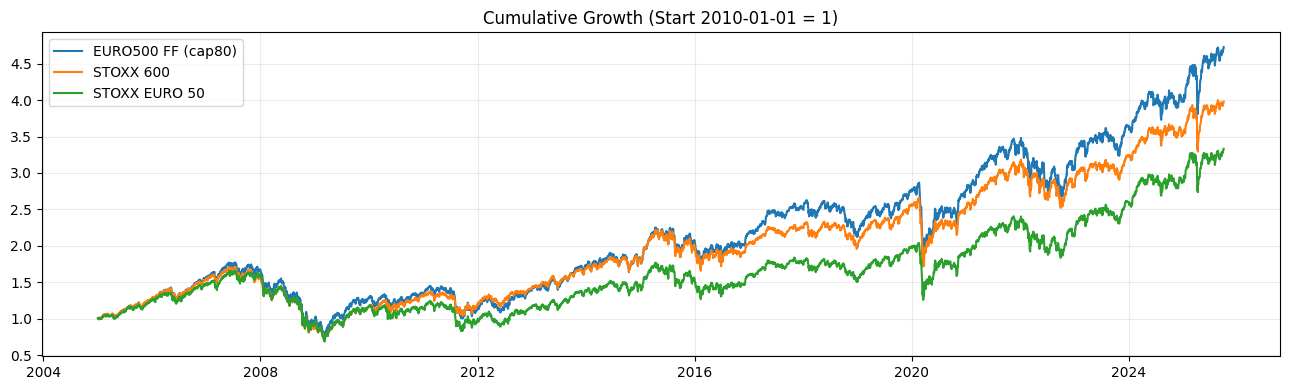

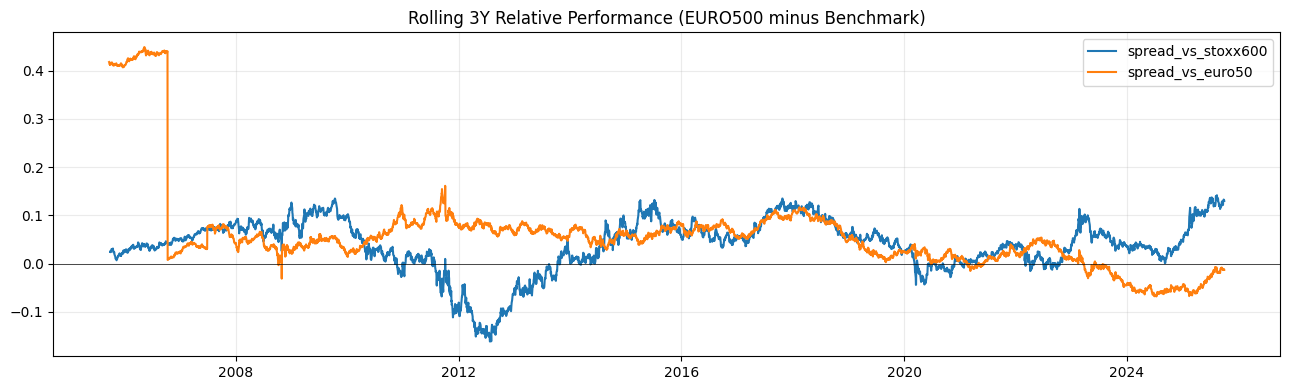

Annual return spread table:


In [7]:
def _normalized_cum_level(ret: pd.Series, base: float = 1.0) -> pd.Series:
    """Convert daily returns into a normalized cumulative level."""
    r = pd.to_numeric(ret, errors="coerce")
    out = (1.0 + r.fillna(0.0)).cumprod() * float(base)
    return out

cmp_plot = cmp_df.copy()
cmp_plot["date"] = pd.to_datetime(cmp_plot["date"], errors="coerce")
cmp_plot = cmp_plot.dropna(subset=["date"]).sort_values("date").reset_index(drop=True)

START_NORM = pd.Timestamp("2005-01-01")
cmp_norm = cmp_plot[cmp_plot["date"] >= START_NORM].copy()

series_cols = [
    "market_return_ffmcap_capped80",
    "stoxx600_ret",
    "stoxx_euro50_ret",
]
series_cols = [c for c in series_cols if c in cmp_norm.columns]

for c in series_cols:
    cmp_norm[f"lvl_{c}"] = _normalized_cum_level(cmp_norm[c])

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
if "lvl_market_return_ffmcap_capped80" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_market_return_ffmcap_capped80"], label="EURO500 FF (cap80)")
if "lvl_stoxx600_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx600_ret"], label="STOXX 600")
if "lvl_stoxx_euro50_ret" in cmp_norm.columns:
    ax.plot(cmp_norm["date"], cmp_norm["lvl_stoxx_euro50_ret"], label="STOXX EURO 50")
ax.set_title("Cumulative Growth (Start 2010-01-01 = 1)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# 3Y (756 trading days) rolling relative performance vs benchmarks
rolling_win = 756
rel = cmp_plot[["date", "market_return_ffmcap_capped80"]].copy()
if "stoxx600_ret" in cmp_plot.columns:
    rel["spread_vs_stoxx600"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx600_ret"]
if "stoxx_euro50_ret" in cmp_plot.columns:
    rel["spread_vs_euro50"] = cmp_plot["market_return_ffmcap_capped80"] - cmp_plot["stoxx_euro50_ret"]

roll = rel[["date"]].copy()
for c in [x for x in rel.columns if x.startswith("spread_")]:
    # Robust rolling sum: allow partial missing observations but require enough valid days.
    valid_cnt = rel[c].notna().rolling(rolling_win, min_periods=1).sum()
    rsum = rel[c].fillna(0.0).rolling(rolling_win, min_periods=252).sum()
    rsum[valid_cnt < 252] = np.nan
    roll[f"roll3y_{c}"] = rsum

fig, ax = plt.subplots(1, 1, figsize=(13, 4))
for c in [x for x in roll.columns if x.startswith("roll3y_")]:
    ax.plot(roll["date"], roll[c], label=c.replace("roll3y_", ""))
ax.axhline(0.0, color="black", lw=0.7, alpha=0.7)
ax.set_title("Rolling 3Y Relative Performance (EURO500 minus Benchmark)")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

# Yearly return spread table
annual = cmp_plot.copy()
annual["year"] = annual["date"].dt.year
ann_rows = []
for y, g in annual.groupby("year"):
    row = {"year": int(y)}
    if g["market_return_ffmcap_capped80"].notna().any():
        row["euro500_ann"] = float((1 + g["market_return_ffmcap_capped80"].fillna(0)).prod() - 1)
    if "stoxx600_ret" in g.columns and g["stoxx600_ret"].notna().any():
        row["stoxx600_ann"] = float((1 + g["stoxx600_ret"].fillna(0)).prod() - 1)
        row["spread_vs_stoxx600"] = row.get("euro500_ann", np.nan) - row["stoxx600_ann"]
    if "stoxx_euro50_ret" in g.columns and g["stoxx_euro50_ret"].notna().any():
        row["stoxx_euro50_ann"] = float((1 + g["stoxx_euro50_ret"].fillna(0)).prod() - 1)
        row["spread_vs_euro50"] = row.get("euro500_ann", np.nan) - row["stoxx_euro50_ann"]
    ann_rows.append(row)

annual_spread = pd.DataFrame(ann_rows).sort_values("year").reset_index(drop=True)
print("Annual return spread table:")

